 ## Email Data Analysis
Email analysis involves extracting insights from email datasets. It includes assessing communication patterns, such as send/receive frequencies. Content analysis using natural language processing reveals keywords, and topics. Visualization techniques represent trends, network structures, and other patterns for comprehensive understanding

In [419]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Converting Gmail Emails to CSV

We have a Gmail dataset in mbox format. This project converts the data into a CSV file for further analysis.

In [420]:
# Loading the mbox file

import mailbox
mbox = mailbox.mbox("..\\All mail Including Spam and Trash.mbox")
mbox

In [421]:
## Displaying the keys of the first email in the mbox to understand the structure of the data

keys2 = list(mbox[0].keys())

if 'From' in mbox[0]:
    print("Key 'From' found in the email keys.")
else:
    print("Key 'From' not found in the email keys.")

Key 'From' found in the email keys.


In [422]:
import csv

with open('../data/email_data.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['From', 'To', 'Subject', 'Date', 'Thread', 'Labels'])
    for message in mbox:
        writer.writerow([message.get('From', ''),
                         message.get('To', ''),
                         message.get('Subject', ''),
                         message.get('Date', ''),
                         message.get('X-GM-THRID', ''),
                         message.get('X-Gmail-Labels', '')])

In [423]:
df = pd.read_csv('../data/email_data.csv')
df.head()

,From,To,Subject,Date,Thread,Labels
0,=?utf-8?q?Indro_Vicari_via_beBee?= <alert@noti...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,"Mon, 13 Nov 2023 17:16:53 +0000",1782469952194646866,"Inbox,Category Updates,Unread"
1,"""Jason @ ML Mastery"" <jason@MachineLearningMas...",bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,"Mon, 13 Nov 2023 15:00:00 +0000 (UTC)",1782461343277158936,"Inbox,Category Updates,Unread"
2,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer a Rome,"Tue, 14 Nov 2023 12:33:11 +0100",1782538925643770298,"Inbox,Category Updates,Unread"
3,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Junior Java Developer a ...,"Wed, 15 Nov 2023 12:33:24 +0100",1782629536219841707,"Inbox,Category Updates,Unread"
4,"""OpenCV.org"" <newsletter@opencv.org>",uzair shafique <bc090402541@gmail.com>,"Donate To Keep OpenCV Free To All, Impact Summ...","Wed, 15 Nov 2023 20:38:11 +0000 (UTC)",1782663811768277342,"Inbox,Category Updates,Unread"


In [424]:
# Converting the 'Date' column to datetime format and handling any parsing errors
df["Date"] = df["Date"].apply(lambda x: pd.to_datetime(x, errors="coerce", utc=True))
df['Date'] = df['Date'].dt.tz_localize(None)
df

,From,To,Subject,Date,Thread,Labels
0,=?utf-8?q?Indro_Vicari_via_beBee?= <alert@noti...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,"""Jason @ ML Mastery"" <jason@MachineLearningMas...",bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,"""OpenCV.org"" <newsletter@opencv.org>",uzair shafique <bc090402541@gmail.com>,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"
...,...,...,...,...,...,...
14729,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer in Rome,2023-10-19 09:41:05,1780176352685898505,"Inbox,Category Updates,Unread"
14730,foodpanda <contact@info.foodpanda.pk>,bc090402541@gmail.com,Khaas deals you wouldn't wanna miss =?UTF-8?B?...,2023-08-13 12:19:49,1774119953401055792,"Inbox,Category Updates,Unread"
14731,=?utf-8?q?Lorenzo__Mancini_via_beBee?= <alert@...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Database_/_SQL_De...,2023-07-21 10:09:09,1772024390878438311,"Inbox,Category Updates,Unread"
14732,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Web Developer in Salerno,2023-08-06 09:56:44,1773473160922129739,"Inbox,Category Updates,Unread"


In [425]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14734 entries, 0 to 14733
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   From     14734 non-null  str           
 1   To       14721 non-null  str           
 2   Subject  14687 non-null  str           
 3   Date     14734 non-null  datetime64[us]
 4   Thread   14734 non-null  int64         
 5   Labels   14734 non-null  str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 690.8 KB


In [426]:
import re

# Function to extract email addresses from a string
def extract_email(email_str):
    if pd.isna(email_str):
        return None
    match = re.findall(r'[\w\.-]+@[\w\.-]+', email_str)
    return match[0] if match else None

df['From'] = df['From'].apply(extract_email)
df['To'] = df['To'].apply(extract_email)
df.head()

,From,To,Subject,Date,Thread,Labels
0,alert@notification.bebee.com,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"


In [427]:

from email.header import decode_header

# Function to decode email subjects that may be encoded in various formats
def clean_subject(subject):
    if pd.isna(subject):
        return None

    decoded_parts = decode_header(subject)
    cleaned_subject = ''
    for part, encoding in decoded_parts:
        if isinstance(part, bytes):
            cleaned_subject += part.decode(encoding or 'utf-8', errors='ignore')
        else:
            cleaned_subject += part
    return cleaned_subject


In [428]:
# Function to further clean the subject by removing common prefixes and extra whitespace
def clean_text(text):
    if pd.isna(text):
        return None

    text = re.sub(r'^(Re:|Fwd:)\s*', '', text, flags=re.IGNORECASE)
    text = text.replace('_',' ')
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['Subject'] = df['Subject'].apply(clean_subject)
df['Subject'] = df['Subject'].apply(clean_text)
df


,From,To,Subject,Date,Thread,Labels
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"
...,...,...,...,...,...,...
14729,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer in Rome,2023-10-19 09:41:05,1780176352685898505,"Inbox,Category Updates,Unread"
14730,contact@info.foodpanda.pk,bc090402541@gmail.com,Khaas deals you wouldn't wanna miss 👉🏻,2023-08-13 12:19:49,1774119953401055792,"Inbox,Category Updates,Unread"
14731,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Database / SQL Developer in...,2023-07-21 10:09:09,1772024390878438311,"Inbox,Category Updates,Unread"
14732,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Web Developer in Salerno,2023-08-06 09:56:44,1773473160922129739,"Inbox,Category Updates,Unread"


In [429]:

# Labeling emails as 'Sent' or 'Received' based on the 'From' field

my_email = "bc09402541@gmail.com"
def label_email(row):
    if row['From'] == my_email:
        return 'Sent'
    else:
        return 'Received'

df['Email_Type'] = df.apply(label_email, axis=1)
df.head()


,From,To,Subject,Date,Thread,Labels,Email_Type
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread",Received
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread",Received
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread",Received
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread",Received
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread",Received


In [430]:
# Extracting the main label from the 'Labels' column to categorize emails into broader categories
def extract_main_label(label):
    if pd.isna(label):
        return "Unknown"

    if "Promotions" in label:
        return "Promotions"
    elif "Social" in label:
        return "Social"
    elif "Updates" in label:
        return "Updates"
    elif "Personal" in label:
        return "Personal"
    elif "Important" in label:
        return "Important"
    else:
        return "Other"

df['Main_Label'] = df['Labels'].apply(extract_main_label)
df[df['Main_Label'].str.contains("Important")].head()

,From,To,Subject,Date,Thread,Labels,Email_Type,Main_Label
2076,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2023-07-10 07:55:38,1771019403880573430,"Sent,Inbox,Important,Opened",Received,Important
2387,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2023-07-10 12:15:09,1771035738767687040,"Sent,Inbox,Important,Opened",Received,Important
6556,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2022-12-27 02:27:52,1753332269670557175,"Sent,Inbox,Important,Opened",Received,Important
7043,bc090402541@gmail.com,bc090402541@gmail.com,I am sharing 'Uzair Shafique (1)' with you,2022-11-03 17:28:33,1748496794610763834,"Sent,Inbox,Important,Opened",Received,Important
8389,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2022-10-13 17:24:21,1746594012769979922,"Sent,Inbox,Important,Opened",Received,Important


In [431]:
# Dropping the 'Labels' and 'Thread' columns as they are no longer needed for analysis
df.drop(columns=['Labels', 'Thread'], inplace=True)

In [432]:
df.head(10)

,From,To,Subject,Date,Email_Type,Main_Label
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,Received,Updates
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,Received,Updates
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,Received,Updates
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,Received,Updates
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,Received,Updates
5,monster@notifications.monster.com,bc090402541@gmail.com,🛎️ Il tuo avviso di lavoro per: Sistemista inf...,2023-11-19 15:02:39,Received,Updates
6,dsml.mit@learn.mygreatlearning.com,bc090402541@gmail.com,[Session Reminder] Predicting Holiday Travel F...,2023-11-13 10:17:16,Received,Updates
7,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Front End Web Developer ...,2023-11-10 10:12:44,Received,Updates
8,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer in...,2023-11-18 11:33:23,Received,Updates
9,mailrobot@mail.xing.com,bc090402541@gmail.com,Radikal Arbeiten: Warum wir eine neue Arbeitsp...,2023-11-09 07:15:01,Received,Promotions


In [433]:
df['domains'] = df['From'].str.extract(r'@([^>]+)')
df

,From,To,Subject,Date,Email_Type,Main_Label,domains
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,Received,Updates,notification.bebee.com
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,Received,Updates,MachineLearningMastery.com
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,Received,Updates,trabajo.org
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,Received,Updates,trabajo.org
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,Received,Updates,opencv.org
...,...,...,...,...,...,...,...
14729,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer in Rome,2023-10-19 09:41:05,Received,Updates,trabajo.org
14730,contact@info.foodpanda.pk,bc090402541@gmail.com,Khaas deals you wouldn't wanna miss 👉🏻,2023-08-13 12:19:49,Received,Updates,info.foodpanda.pk
14731,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Database / SQL Developer in...,2023-07-21 10:09:09,Received,Updates,notification.bebee.com
14732,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Web Developer in Salerno,2023-08-06 09:56:44,Received,Updates,trabajo.org


In [434]:
top_senders = df['domains'].value_counts().head(10).reset_index()
top_senders.columns = ['domain', 'count']
top_senders

,domain,count
0,trabajo.org,1845
1,notification.bebee.com,1737
2,glassdoor.com,1074
3,mustakbil.com,845
4,m.photoserge.com,716
5,wish.com,566
6,talent.com,456
7,info.foodpanda.pk,390
8,indeed.com,367
9,jobsora.com,328


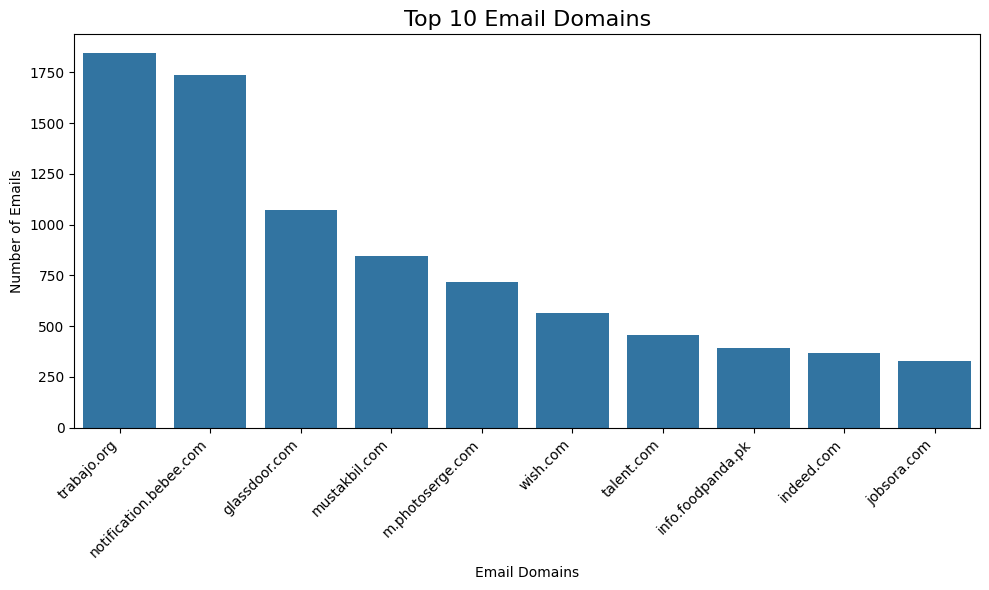

In [435]:

plt.figure(figsize=(10, 6))
sns.barplot(data=top_senders, x='domain', y='count')
plt.title("Top 10 Email Domains", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Emails")
plt.xlabel("Email Domains")
plt.tight_layout()
plt.show()



A small number of domains dominate email traffic, with domains like trabajo.org 
and bebee.com contributing the highest volume of emails. This suggests that most communication originates from a limited number of platforms, 
likely job portals or automated notification systems.

In [436]:
# weekday and month extraction
df['weekday'] = df['Date'].dt.day_name()
df['months'] = df['Date'].dt.month_name()
df['months_num'] = df['Date'].dt.month
df['hours']= df['Date'].dt.hour


In [437]:
df.head()

,From,To,Subject,Date,Email_Type,Main_Label,domains,weekday,months,months_num,hours
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,Received,Updates,notification.bebee.com,Monday,November,11,17
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,Received,Updates,MachineLearningMastery.com,Monday,November,11,15
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,Received,Updates,trabajo.org,Tuesday,November,11,11
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,Received,Updates,trabajo.org,Wednesday,November,11,11
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,Received,Updates,opencv.org,Wednesday,November,11,20


In [438]:
# Count emails by weekday to identify patterns in email communication across different days of the week
weekdays_count = df['weekday'].value_counts().reset_index()
weekdays_count.columns = ['weekday', 'count']
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [439]:
heatmap = df.pivot_table(index='weekday', columns='hours', aggfunc='size',fill_value=0)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap = heatmap.reindex(order)


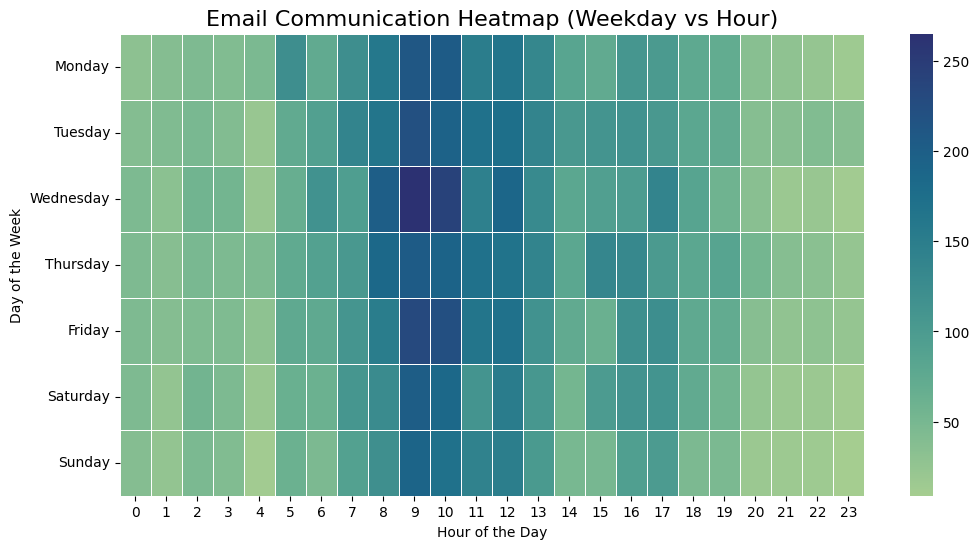

In [440]:
# Plotting heatmap of email communication by weekday and hour to visualize patterns in email communication across different times of the day and days of the week
plt.figure(figsize=(12, 6))
ax = sns.heatmap(heatmap, cmap='crest', linewidths=.6)
plt.title("Email Communication Heatmap (Weekday vs Hour)", fontsize=16)
plt.xlabel("Hour of the Day")
plt.ylabel ("Day of the Week")
plt.show()


Email activity peaks during weekday mornings, especially between 9 AM and 11 AM, 
with Wednesday showing the highest intensity. Activity declines significantly 
during late evenings and weekends, indicating standard work-hour communication patterns

C:\Users\user\AppData\Local\Temp\ipykernel_21196\621942135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekdays_count, x='weekday', y='count', order=order, palette='crest')


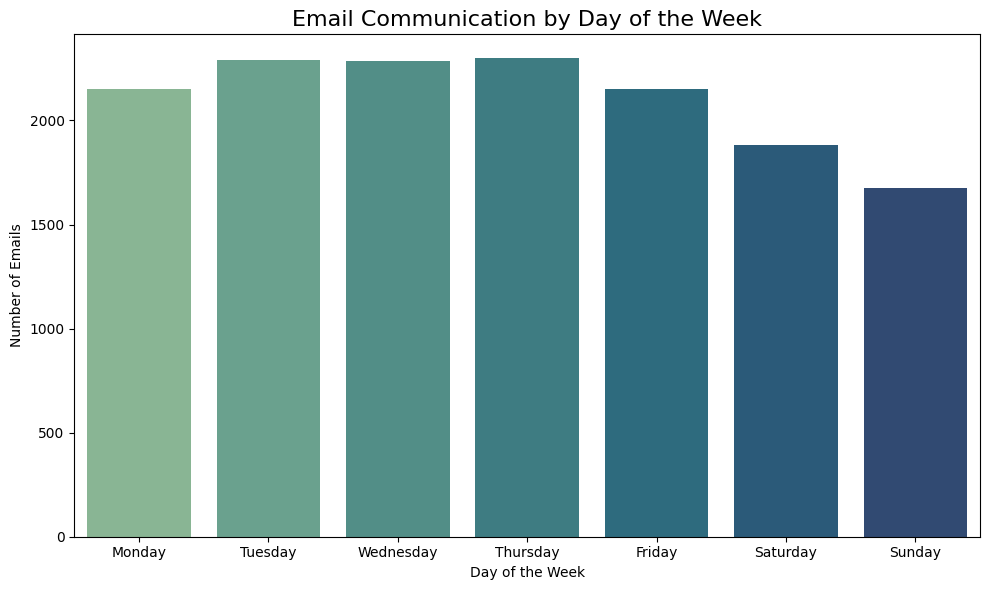

In [441]:

# Plotting the number of emails received/sent on each day of the week to identify patterns in email communication
plt.figure(figsize=(10, 6))
sns.barplot(data=weekdays_count, x='weekday', y='count', order=order, palette='crest')
plt.title("Email Communication by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()


Email activity is highest during weekdays, particularly from Tuesday to Thursday,
while weekends show a noticeable decline. This indicates that most emails are 
work-related and follow typical business communication patterns

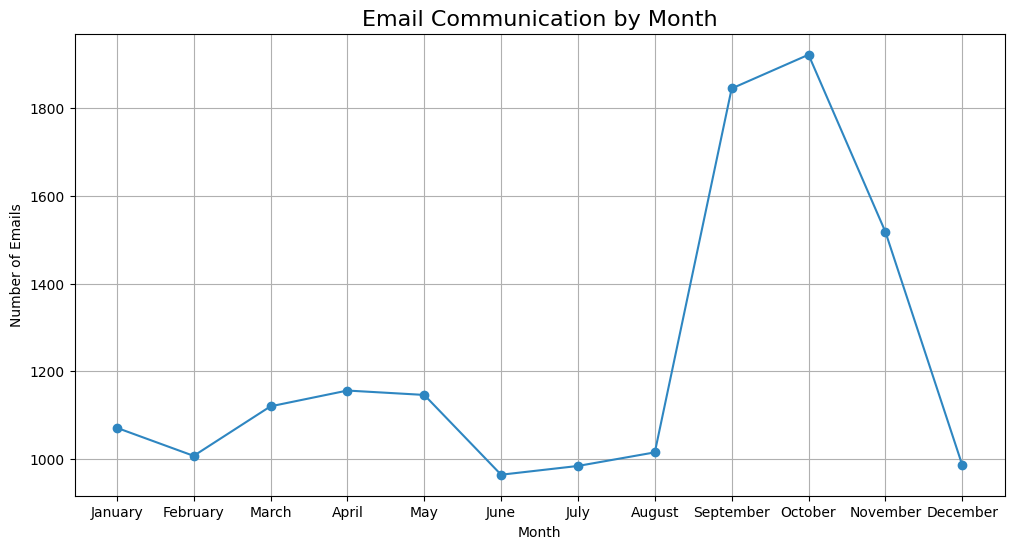

In [442]:
# Analyzing email communication patterns by month to identify trends in email activity throughout the year
months_count = df.groupby(['months', 'months_num']).size().reset_index(name='total_size')
months_count = months_count.sort_values('months_num')

plt.figure(figsize=(12, 6))
plt.plot(months_count['months'], months_count['total_size'], marker='o', linestyle='-', color='#2E86C1')
plt.title("Email Communication by Month", fontsize=16)
plt.xlabel("Month")
plt.grid(True)
plt.ylabel("Number of Emails")
plt.show()

Email activity remains relatively stable in the first half of the year, 
but shows a sharp increase in September and October, indicating peak communication periods. 
This suggests seasonal or business-driven spikes in email activity